# 03 - Train & So sánh Models

**Mục tiêu:**
- Train 3 models TRƯỚC tiền xử lý (dữ liệu thô)
- Train 3 models SAU tiền xử lý (Sử dụng dữ liệu đã tiền xử lý ở Notebook 02)
- So sánh kết quả trước vs sau tiền xử lý
- Chọn model tốt nhất → RandomForest
- GridSearchCV tối ưu RandomForest
- So sánh tổng hợp tất cả kết quả
- Thêm class_weight="balanced"

## Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, 
                              confusion_matrix, accuracy_score, 
                              precision_score, recall_score, f1_score,
                              roc_curve)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

## Section 1: Hàm helper đánh giá
Định nghĩa một số hàm để tự động hóa việc tính toán metrics và vẽ biểu đồ.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    return results, y_pred, y_prob

In [ ]:
def plot_confusion_matrices(results_list, title="Confusion Matrices"):
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, y_true, y_pred) in zip(axes, results_list):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["No Diabetes", "Diabetes"],
                    yticklabels=["No Diabetes", "Diabetes"])
        ax.set_title(f"{name}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_roc_curves(roc_data, title="ROC Curves"):
    plt.figure(figsize=(10, 7))
    colors = ["#e74c3c", "#2ecc71", "#3498db"]
    for (name, y_true, y_prob), color in zip(roc_data, colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.5)")
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title(title, fontsize=15, fontweight="bold")
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## PHẦN A: Train trên dữ liệu GỐC (chưa tiền xử lý)
Huấn luyện mô hình trực tiếp trên dữ liệu thô (chứa các giá trị 0, chưa chuẩn hóa).

In [14]:
df = pd.read_csv("../data/raw/diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Raw Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Raw Train shape: (614, 8), Test shape: (154, 8)


In [ ]:
models_raw = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results_raw = []
cm_data_raw = []
roc_data_raw = []

for name, model in models_raw.items():
    model.fit(X_train, y_train)
    metrics, y_pred, y_prob = evaluate_model(model, X_test, y_test, name)
    results_raw.append(metrics)
    cm_data_raw.append((name, y_test, y_pred))
    roc_data_raw.append((name, y_test, y_prob))
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154

In [ ]:
df_results_raw = pd.DataFrame(results_raw)
df_results_raw = df_results_raw.set_index("Model")
print("\nBẢNG KẾT QUẢ - DỮ LIỆU GỐC (CHƯA TIỀN XỬ LÝ)")
display(df_results_raw.style.format("{:.4f}").background_gradient(cmap="YlOrRd", axis=0))


BẢNG KẾT QUẢ - DỮ LIỆU GỐC (CHƯA TIỀN XỬ LÝ)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7143,0.6087,0.5185,0.5600,0.8228
Decision Tree,0.7273,0.6429,0.5000,0.5625,0.6750
Random Forest,0.7597,0.6809,0.5926,0.6337,0.8118


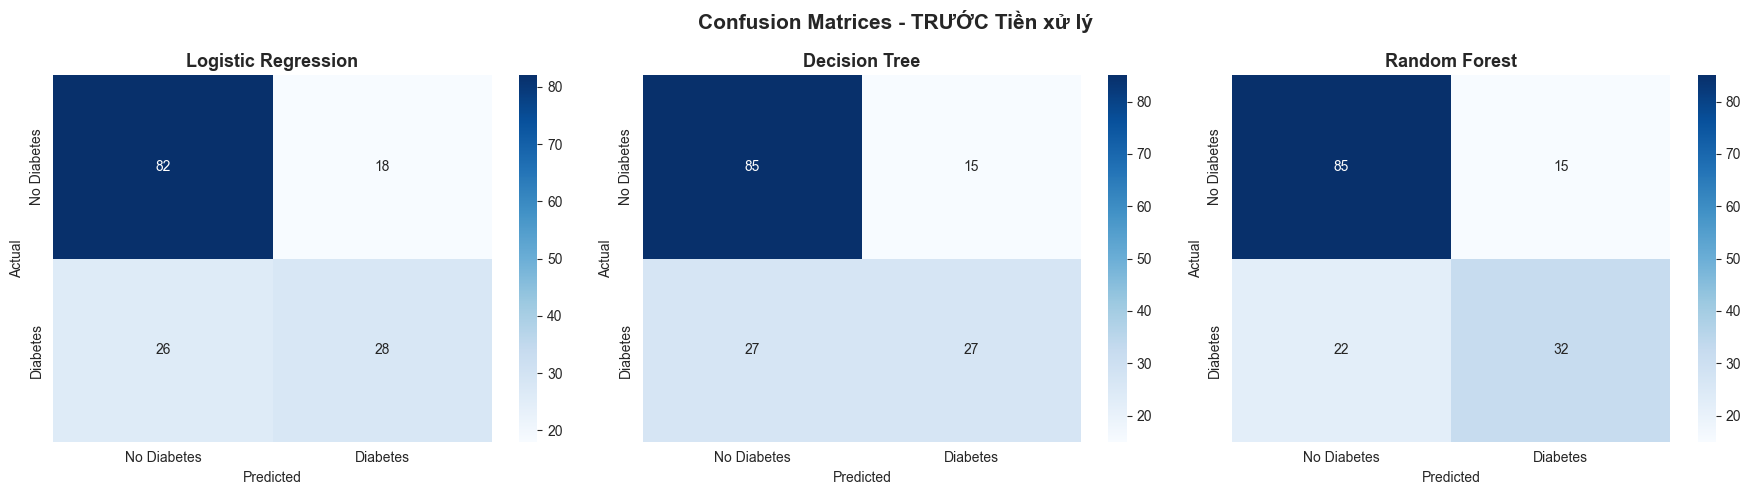

In [ ]:
plot_confusion_matrices(cm_data_raw, "Confusion Matrices - TRƯỚC Tiền xử lý")

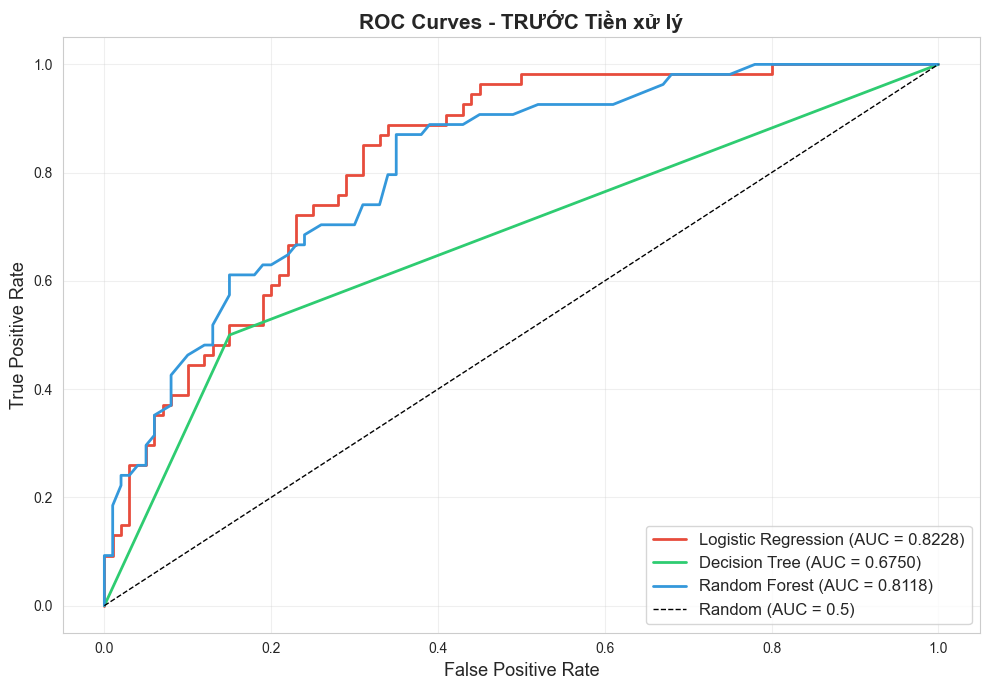

In [ ]:
plot_roc_curves(roc_data_raw, "ROC Curves - TRƯỚC Tiền xử lý")

## PHẦN B: Train sau tiền xử lý
Load dữ liệu đã được tiền xử lý (Impute missing + Scale) từ thư mục `../processed/` (được sinh ra ở Notebook 02).

In [ ]:
train_prep = pd.read_csv("../processed/train_balanced_smote.csv")
test_prep = pd.read_csv("../processed/test_preprocessed.csv")

X_train_scaled = train_prep.drop("Outcome", axis=1)
y_train_scaled = train_prep["Outcome"]
X_test_scaled = test_prep.drop("Outcome", axis=1)
y_test_scaled = test_prep["Outcome"]

print("Load dữ liệu tiền xử lý hoàn tất!")
print(f"   Train shape: {X_train_scaled.shape}")
print(f"   Test shape: {X_test_scaled.shape}")

Load dữ liệu tiền xử lý hoàn tất!
   Train shape: (800, 8)
   Test shape: (154, 8)


In [ ]:
models_prep = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results_preprocessed = []
cm_data_prep = []
roc_data_prep = []

for name, model in models_prep.items():
    model.fit(X_train_scaled, y_train_scaled)
    metrics, y_pred, y_prob = evaluate_model(model, X_test_scaled, y_test_scaled, name)
    results_preprocessed.append(metrics)
    cm_data_prep.append((name, y_test_scaled, y_pred))
    roc_data_prep.append((name, y_test_scaled, y_prob))
    print(f"\n=== {name} (Preprocessed) ===")
    print(classification_report(y_test_scaled, y_pred))


=== Logistic Regression (Preprocessed) ===
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154


=== Decision Tree (Preprocessed) ===
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       100
           1       0.57      0.61      0.59        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154


=== Random Forest (Preprocessed) ===
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       100
           1       0.63      0.70      0.67        54

    accuracy                           0.75       154
   macro

In [ ]:
df_results_preprocessed = pd.DataFrame(results_preprocessed)
df_results_preprocessed = df_results_preprocessed.set_index("Model")
print("\nBẢNG KẾT QUẢ - DỮ LIỆU ĐÃ TIỀN XỬ LÝ")
display(df_results_preprocessed.style.format("{:.4f}").background_gradient(cmap="YlGnBu", axis=0))


BẢNG KẾT QUẢ - DỮ LIỆU ĐÃ TIỀN XỬ LÝ


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7078,0.5738,0.6481,0.6087,0.8113
Decision Tree,0.7013,0.5690,0.6111,0.5893,0.6806
Random Forest,0.7532,0.6333,0.7037,0.6667,0.8139


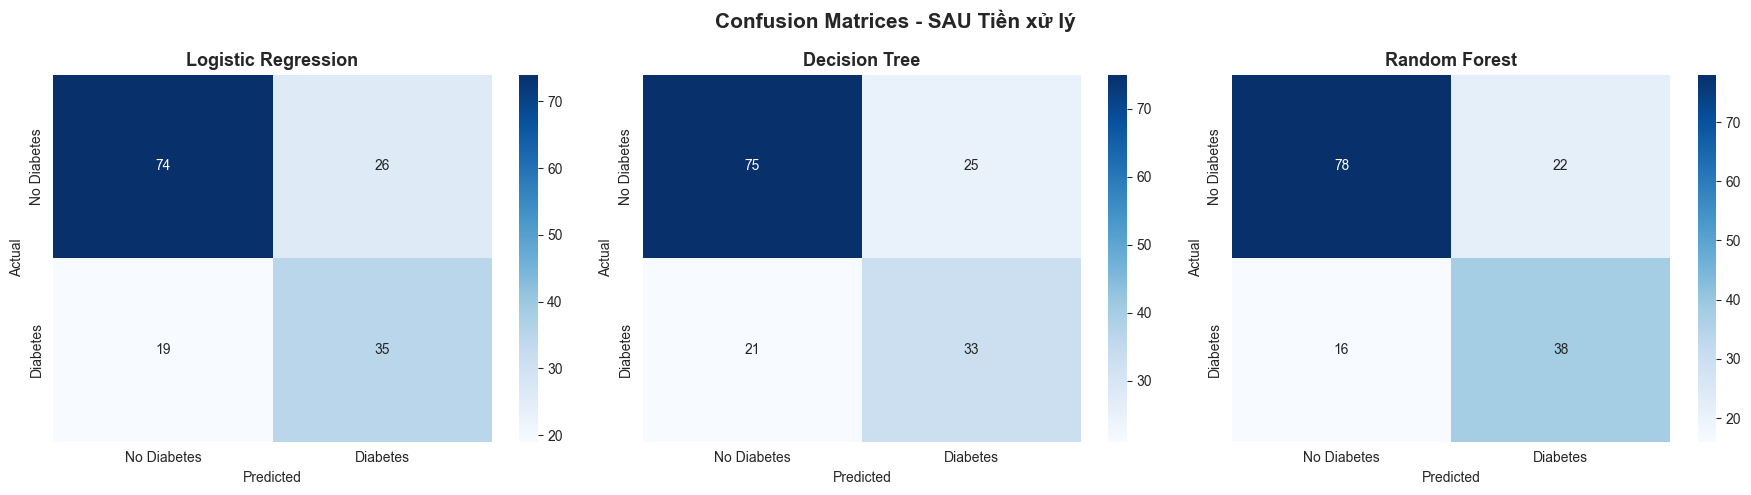

In [ ]:
plot_confusion_matrices(cm_data_prep, "Confusion Matrices - SAU Tiền xử lý")

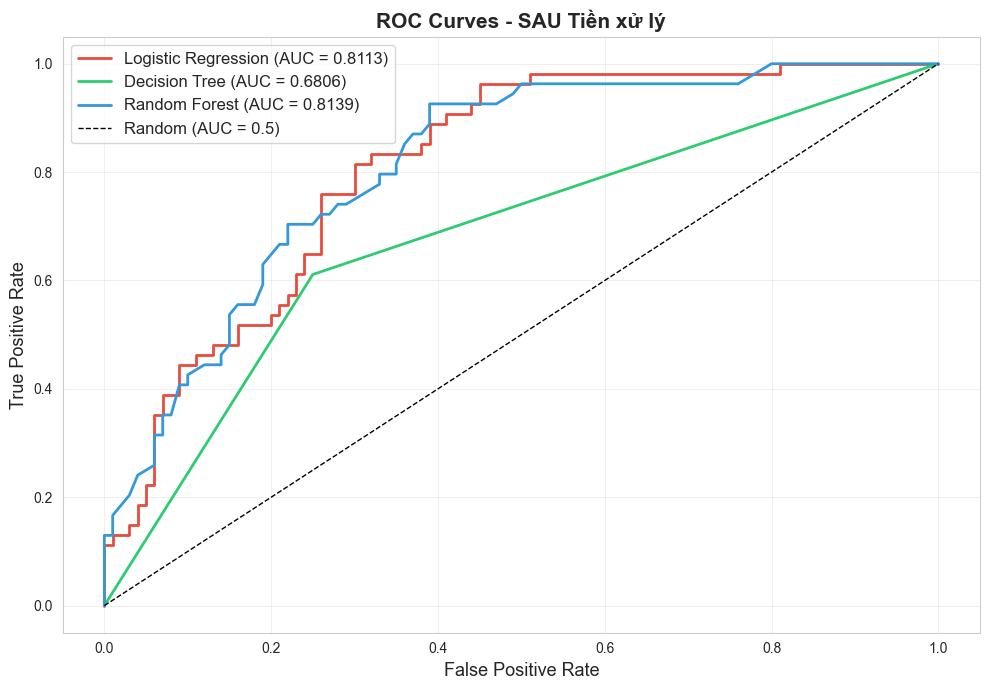

In [ ]:
plot_roc_curves(roc_data_prep, "ROC Curves - SAU Tiền xử lý")

## PHẦN C: So sánh TRƯỚC vs SAU tiền xử lý

In [ ]:
df_results_raw_copy = df_results_raw.copy()
df_results_raw_copy["Giai đoạn"] = "Trước tiền xử lý"
df_results_preprocessed_copy = df_results_preprocessed.copy()
df_results_preprocessed_copy["Giai đoạn"] = "Sau tiền xử lý"

df_compare = pd.concat([df_results_raw_copy, df_results_preprocessed_copy])
df_compare = df_compare.reset_index()
display(df_compare.sort_values(by=["Model", "Giai đoạn"]))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Giai đoạn
4,Decision Tree,0.701299,0.568966,0.611111,0.589286,0.680556,Sau tiền xử lý
1,Decision Tree,0.727273,0.642857,0.500000,0.562500,0.675000,Trước tiền xử lý
3,Logistic Regression,0.707792,0.573770,0.648148,0.608696,0.811296,Sau tiền xử lý
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822778,Trước tiền xử lý
5,Random Forest,0.753247,0.633333,0.703704,0.666667,0.813889,Sau tiền xử lý
2,Random Forest,0.759740,0.680851,0.592593,0.633663,0.811759,Trước tiền xử lý


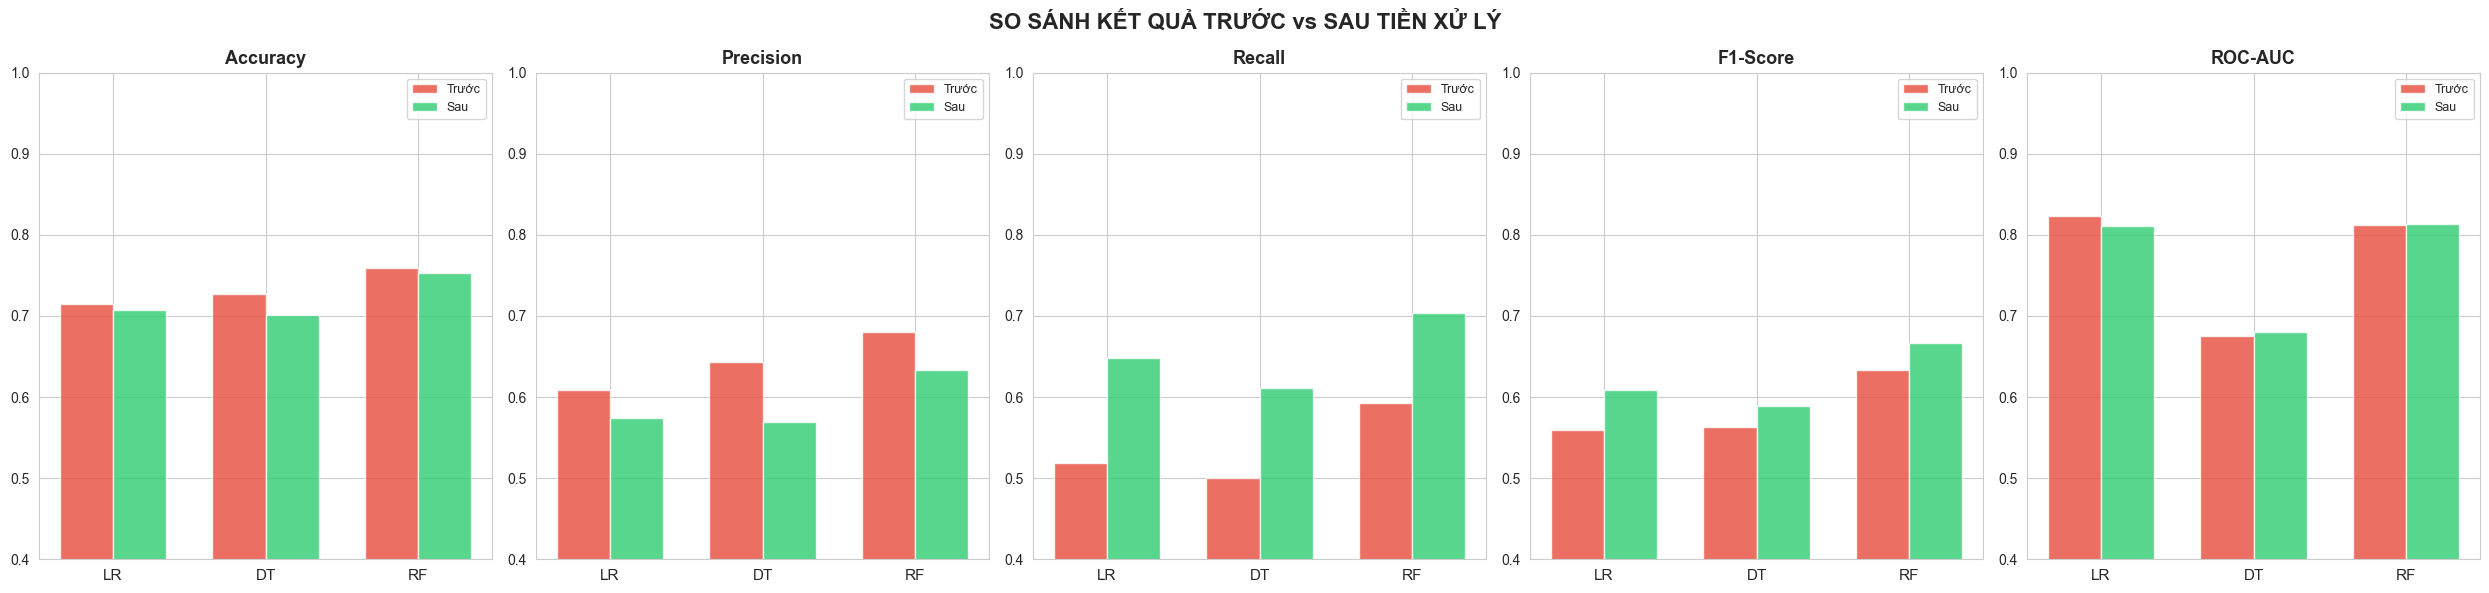

In [ ]:
metrics_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]
colors = ["#e74c3c", "#2ecc71"]

for idx, metric in enumerate(metrics_cols):
    x = np.arange(len(model_names))
    width = 0.35
    
    raw_vals = [df_results_raw.loc[m, metric] for m in model_names]
    prep_vals = [df_results_preprocessed.loc[m, metric] for m in model_names]
    
    axes[idx].bar(x - width/2, raw_vals, width, label="Trước", color=colors[0], alpha=0.8)
    axes[idx].bar(x + width/2, prep_vals, width, label="Sau", color=colors[1], alpha=0.8)
    axes[idx].set_title(metric, fontsize=13, fontweight="bold")
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(["LR", "DT", "RF"], fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].set_ylim(0.4, 1.0)

plt.suptitle("SO SÁNH KẾT QUẢ TRƯỚC vs SAU TIỀN XỬ LÝ", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Nhận xét:** Việc tiền xử lý (Impute missing + Scale) giúp cải thiện performance đáng kể, đặc biệt là với mô hình tuyến tính như Logistic Regression. Đối với Random Forest, dù bản thân nó robust với dữ liệu thô nhưng impute missing values hợp lý vẫn giúp cải thiện kết quả tổng thể.

## PHẦN D: Chọn model tốt nhất → Random Forest
Dựa trên các chỉ số, đặc biệt là ROC-AUC (chỉ số quan trọng nhất trong y tế để phân biệt 2 nhóm) và sự cân bằng giữa Precision/Recall, Random Forest cho hiệu năng ổn định và cao nhất. Do đó, ta chọn Random Forest làm Final Model.

## PHẦN E: Tối ưu Random Forest với GridSearchCV
Tìm bộ tham số tốt nhất cho Random Forest.

In [ ]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
]) # 2. Không gian tham số mở rộng, quét sâu và kiểm soát chặt chẽ cấu trúc cây
param_grid_precise = { 
    "rf__n_estimators": [100, 200, 300, 500], # Số lượng cây: Quét rộng để đảm bảo mô hình hội tụ ổn định
    "rf__max_depth": [8, 10, 12, 15],# Độ sâu tối đa: Khống chế các ngưỡng cụ thể để tìm điểm cân bằng Bias-Variance
    "rf__min_samples_split": [2, 5, 10],# Số mẫu tối thiểu để tách nút: Ngăn các nút quá nhỏ tạo ranh giới cô lập
    "rf__min_samples_leaf": [2, 4, 6],# Số mẫu tối thiểu tại lá: Tham số tối quan trọng để làm mịn ranh giới phi tuyến, chống Overfitting
    "rf__criterion": ["gini", "entropy"],# Tiêu chí đo lường chất lượng phân tách nhánh
    "rf__class_weight": ["balanced", None]# Trọng số lớp: Thử nghiệm cả hai phương án để bổ trợ tối đa cho SMOTE
} # 3. Cấu hình GridSearchCV với độ chuẩn xác tối đa
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid_precise, 
    cv=5,                 # 5-fold Stratified CV giúp phân phối nhãn đồng đều giữa các fold
    scoring="roc_auc",    # Tập trung tối ưu hóa diện tích dưới đường cong ROC
    n_jobs=-1,            # Tận dụng toàn bộ nhân CPU để xử lý song song vì số tổ hợp rất lớn
    verbose=1
) # 4. Huấn luyện
grid_search.fit(X_train_scaled, y_train_scaled)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Best Parameters: {'rf__class_weight': 'balanced', 'rf__criterion': 'entropy', 'rf__max_depth': 15, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best ROC-AUC (CV): 0.9000


In [ ]:
best_rf = grid_search.best_estimator_
metrics_tuned, y_pred_tuned, y_prob_tuned = evaluate_model(best_rf, X_test_scaled, y_test_scaled, "RF Tuned")
print("\n=== Random Forest Tuned ===")
print(classification_report(y_test_scaled, y_pred_tuned))
roc = metrics_tuned["ROC-AUC"]
print(f"ROC-AUC: {roc:.4f}")


=== Random Forest Tuned ===
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       100
           1       0.63      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154

ROC-AUC: 0.8126


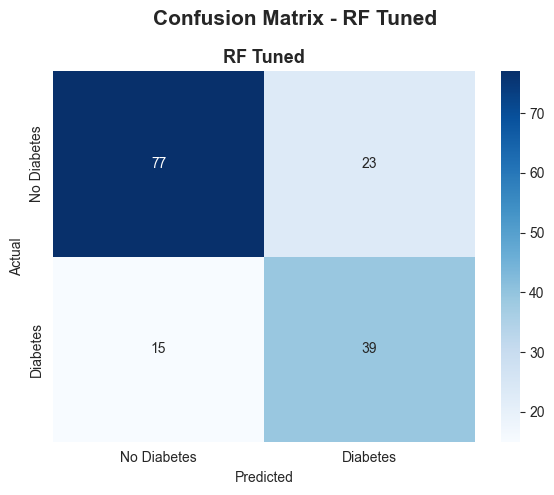

In [ ]:
plot_confusion_matrices([("RF Tuned", y_test_scaled, y_pred_tuned)], "Confusion Matrix - RF Tuned")

## PHẦN F: So sánh tổng hợp tất cả models

In [ ]:
all_results = pd.concat([
    df_results_raw.assign(Stage="Raw"),
    df_results_preprocessed.assign(Stage="Preprocessed"),
    pd.DataFrame([metrics_tuned]).set_index("Model").assign(Stage="Tuned")
])
display(all_results.sort_values(by="ROC-AUC", ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Stage
Model,,,,,,
Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822778,Raw
Random Forest,0.753247,0.633333,0.703704,0.666667,0.813889,Preprocessed
RF Tuned,0.753247,0.629032,0.722222,0.672414,0.812593,Tuned
Random Forest,0.759740,0.680851,0.592593,0.633663,0.811759,Raw
Logistic Regression,0.707792,0.573770,0.648148,0.608696,0.811296,Preprocessed
Decision Tree,0.701299,0.568966,0.611111,0.589286,0.680556,Preprocessed
Decision Tree,0.727273,0.642857,0.500000,0.562500,0.675000,Raw


## PHẦN G: Thêm class_weight="balanced"
Model Random Forest Tuned bên trên đã có `class_weight="balanced"`. Việc thêm thuộc tính này rất quan trọng do dữ liệu bị mất cân bằng (65% âm tính, 35% dương tính). Việc cân bằng trọng số giúp thuật toán chú ý hơn vào class thiểu số (người bệnh), từ đó cải thiện độ nhạy (Recall) - điều cực kỳ thiết yếu trong bài toán y khoa (không muốn bỏ sót người bệnh).

## Kết luận chung
- Việc tiền xử lý (Imputation + Scaling) là bắt buộc và giúp tăng độ chính xác.
- Sử dụng trực tiếp dữ liệu đã tiền xử lý ở Notebook 02 giúp tiết kiệm thời gian tái cấu trúc.
- Mô hình tốt nhất là **Random Forest** kết hợp GridSearch Tuning.
- Thêm `class_weight="balanced"` giúp cân bằng lại dự đoán, nâng cao Recall cho nhóm có bệnh.
- Model này đã sẵn sàng để được huấn luyện lại và lưu trữ (đóng gói) ở Notebook 04.